# EDA — Smart Farming MLOps
### Analyse exploratoire des données (Crop Recommendation & Yield)

**Auteur :** Layla Ouarrak — Personne 3 (Analytics & Transformation)  
**Source des données :** DuckDB, tables `sf_data.mart_crop_recommendation` et `sf_data.mart_yield`  
**Objectif :** explorer les données transformées par dbt avant leur utilisation dans les modèles ML (classification + régression).

## 1. Connexion à la base de données

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Connexion à la base DuckDB (lecture seule pour ne rien casser)
con = duckdb.connect(
    database=r"C:\Users\Layla Ouarrak\Desktop\smart-farming-mlops-\data\warehouse\smart_farming.duckdb",
    read_only=True
)

print("Connexion réussie ")

Connexion réussie 


## 2. Chargement des données

In [3]:
# Charger les 2 tables mart dans des DataFrames pandas
df_crop = con.execute("SELECT * FROM sf_data.mart_crop_recommendation").fetchdf()
df_yield = con.execute("SELECT * FROM sf_data.mart_yield").fetchdf()

print("df_crop  :", df_crop.shape)
print("df_yield :", df_yield.shape)

df_crop.head()

df_crop  : (2200, 13)
df_yield : (56717, 7)


,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,crop_label,npk_total,np_ratio,nk_ratio,heat_humidity,rain_temp
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice,175.0,2.142857,2.093023,17.121963,4237.241986
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice,184.0,1.465517,2.073171,17.485957,4934.395694
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice,159.0,1.090909,1.363636,18.937446,6072.354751
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice,149.0,2.114286,1.850000,21.234829,6433.734530
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice,162.0,1.857143,1.857143,16.427204,5288.545993


In [4]:
df_yield.head()

,country,crop,year,year_norm,yield_hg_ha,yield_tonnes_per_ha,log_yield
0,Afghanistan,Maize,1961,0,14000.0,1.400,9.546884
1,Afghanistan,Maize,1962,1,14000.0,1.400,9.546884
2,Afghanistan,Maize,1963,2,14260.0,1.426,9.565284
3,Afghanistan,Maize,1964,3,14257.0,1.426,9.565073
4,Afghanistan,Maize,1965,4,14400.0,1.440,9.575053


## 3. Qualité des données
Avant toute analyse, on vérifie qu'il n'y a pas de valeurs manquantes ni de doublons cachés — même si les tests dbt (12/12 PASS) l'ont déjà validé, c'est une bonne pratique de le revérifier ici.

In [5]:
# Valeurs manquantes
print("=== Valeurs manquantes — df_crop ===")
print(df_crop.isnull().sum())
print()
print("=== Valeurs manquantes — df_yield ===")
print(df_yield.isnull().sum())

=== Valeurs manquantes — df_crop ===
nitrogen         0
phosphorus       0
potassium        0
temperature      0
humidity         0
ph               0
rainfall         0
crop_label       0
npk_total        0
np_ratio         0
nk_ratio         0
heat_humidity    0
rain_temp        0
dtype: int64

=== Valeurs manquantes — df_yield ===
country                0
crop                   0
year                   0
year_norm              0
yield_hg_ha            0
yield_tonnes_per_ha    0
log_yield              0
dtype: int64


In [6]:
# Doublons
print(f"Doublons dans df_crop  : {df_crop.duplicated().sum()}")
print(f"Doublons dans df_yield : {df_yield.duplicated().sum()}")

Doublons dans df_crop  : 0
Doublons dans df_yield : 0


## 4. Statistiques descriptives

In [7]:
print("=== Statistiques df_crop ===")
df_crop.describe()

=== Statistiques df_crop ===


,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,npk_total,np_ratio,nk_ratio,heat_humidity,rain_temp
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,152.063636,1.701689,1.670538,18.542316,2641.981853
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,79.918669,2.573334,1.507555,6.993663,1540.638535
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,17.000000,0.000000,0.000000,2.476132,560.388343
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,94.000000,0.350000,0.559706,14.795581,1476.424780
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,146.000000,0.890909,1.388322,19.278833,2273.703287
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,179.000000,1.977399,2.167453,22.557524,3380.593150
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,385.000000,23.799995,9.333333,40.731596,10577.199852


In [8]:
print("=== Statistiques df_yield ===")
df_yield.describe()

=== Statistiques df_yield ===


,year,year_norm,yield_hg_ha,yield_tonnes_per_ha,log_yield
count,56717.000000,56717.000000,56717.000000,56717.000000,56717.000000
mean,1989.669570,28.669570,62094.660084,6.209509,10.495559
std,16.133198,16.133198,67835.932856,6.783596,1.093238
min,1961.000000,0.000000,0.000000,0.000000,0.000000
25%,1976.000000,15.000000,15680.000000,1.568000,9.660205
50%,1991.000000,30.000000,36744.000000,3.674000,10.511757
75%,2004.000000,43.000000,86213.000000,8.621000,11.364588
max,2016.000000,55.000000,1000000.000000,100.000000,13.815512


### Vérification des rendements à zéro
On avait repéré que `yield_hg_ha` a un minimum de 0. On vérifie combien de lignes sont concernées, et si c'est négligeable.

In [9]:
zero_yield = df_yield[df_yield["yield_hg_ha"] == 0]
print(f"Nombre de lignes avec rendement = 0 : {len(zero_yield)}")
print(f"Pourcentage du total : {len(zero_yield) / len(df_yield) * 100:.2f}%")
zero_yield.head()

Nombre de lignes avec rendement = 0 : 8
Pourcentage du total : 0.01%


,country,crop,year,year_norm,yield_hg_ha,yield_tonnes_per_ha,log_yield
35804,New Caledonia,Sorghum,2000,39,0.0,0.0,0.0
35806,New Caledonia,Sorghum,2012,51,0.0,0.0,0.0
35906,New Caledonia,Wheat,2000,39,0.0,0.0,0.0
35908,New Caledonia,Wheat,2002,41,0.0,0.0,0.0
35912,New Caledonia,Wheat,2006,45,0.0,0.0,0.0


## 5. Distribution des cultures (df_crop)

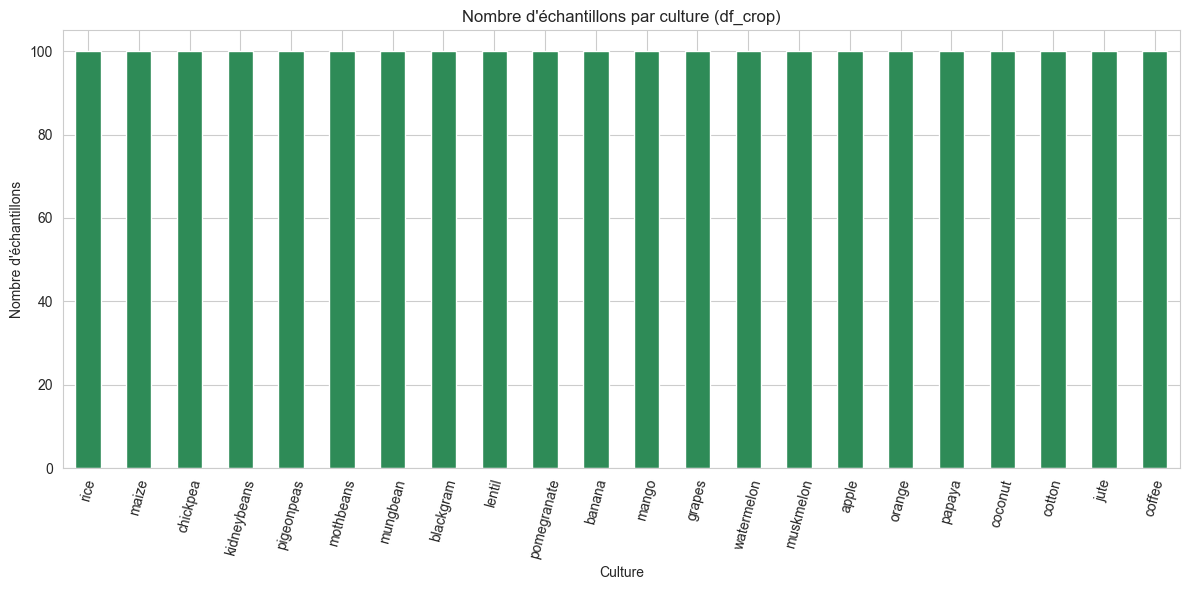

In [10]:
plt.figure(figsize=(12, 6))
df_crop["crop_label"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Nombre d'échantillons par culture (df_crop)")
plt.xlabel("Culture")
plt.ylabel("Nombre d'échantillons")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 6. Détection des valeurs aberrantes (outliers)
Les boxplots permettent de repérer visuellement des valeurs extrêmes qui pourraient fausser un modèle ML.

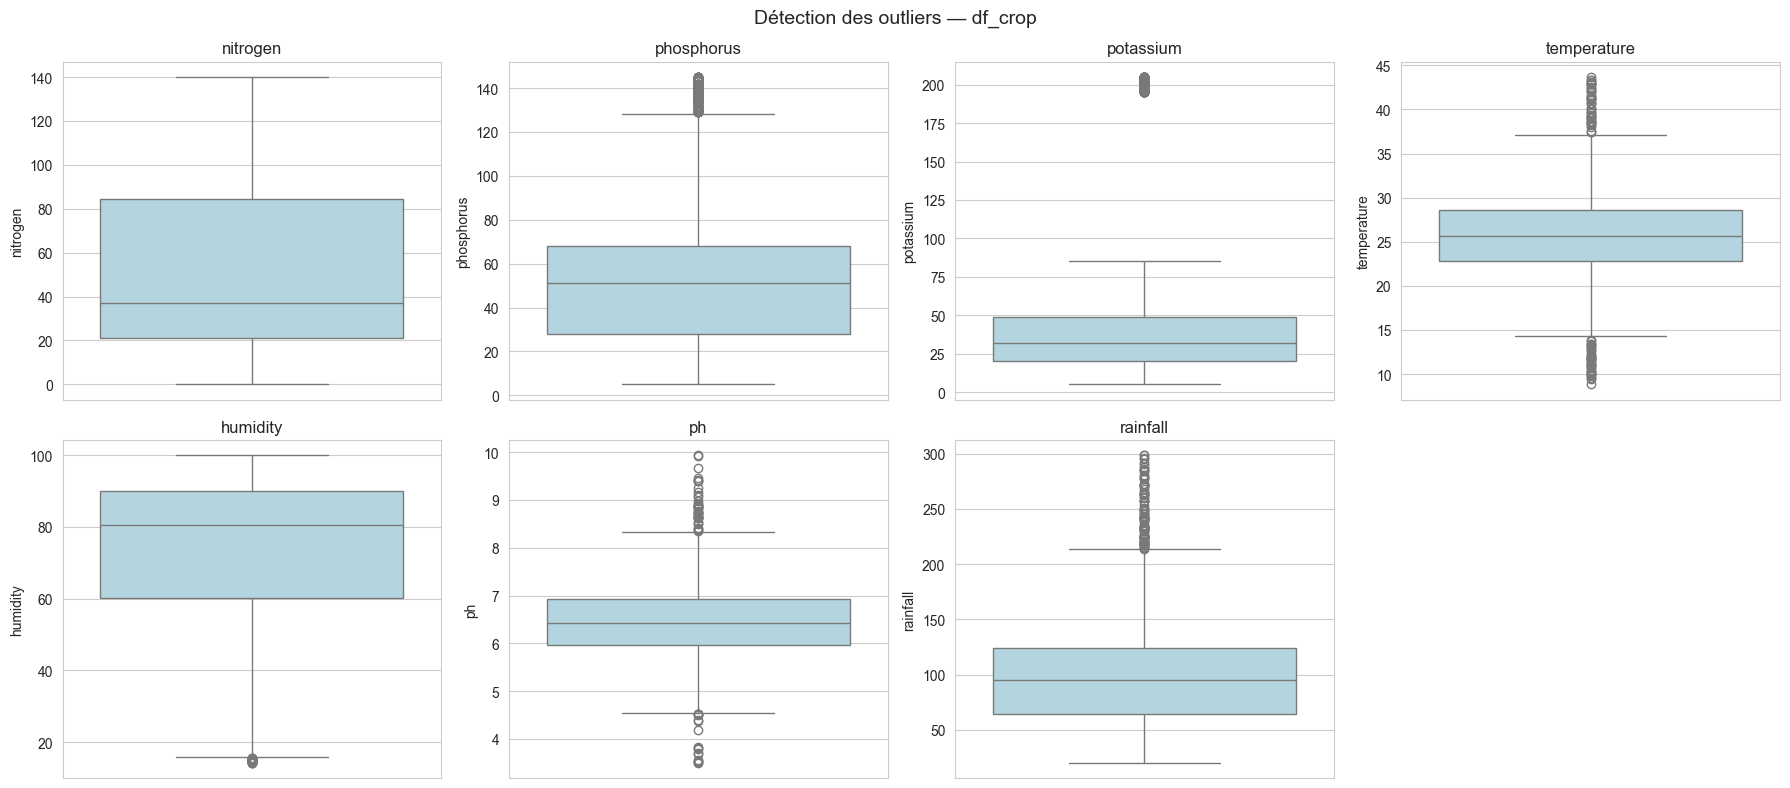

In [11]:
numeric_cols = ["nitrogen", "phosphorus", "potassium", "temperature", "humidity", "ph", "rainfall"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_crop[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col)

# Cacher la dernière case vide (8 cases, 7 variables)
axes[-1].axis("off")

plt.suptitle("Détection des outliers — df_crop", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Corrélations entre variables
On inclut aussi les features engineerées (`npk_total`, `np_ratio`, `nk_ratio`, `heat_humidity`, `rain_temp`) créées dans le mart dbt, alignées avec le modèle ML.

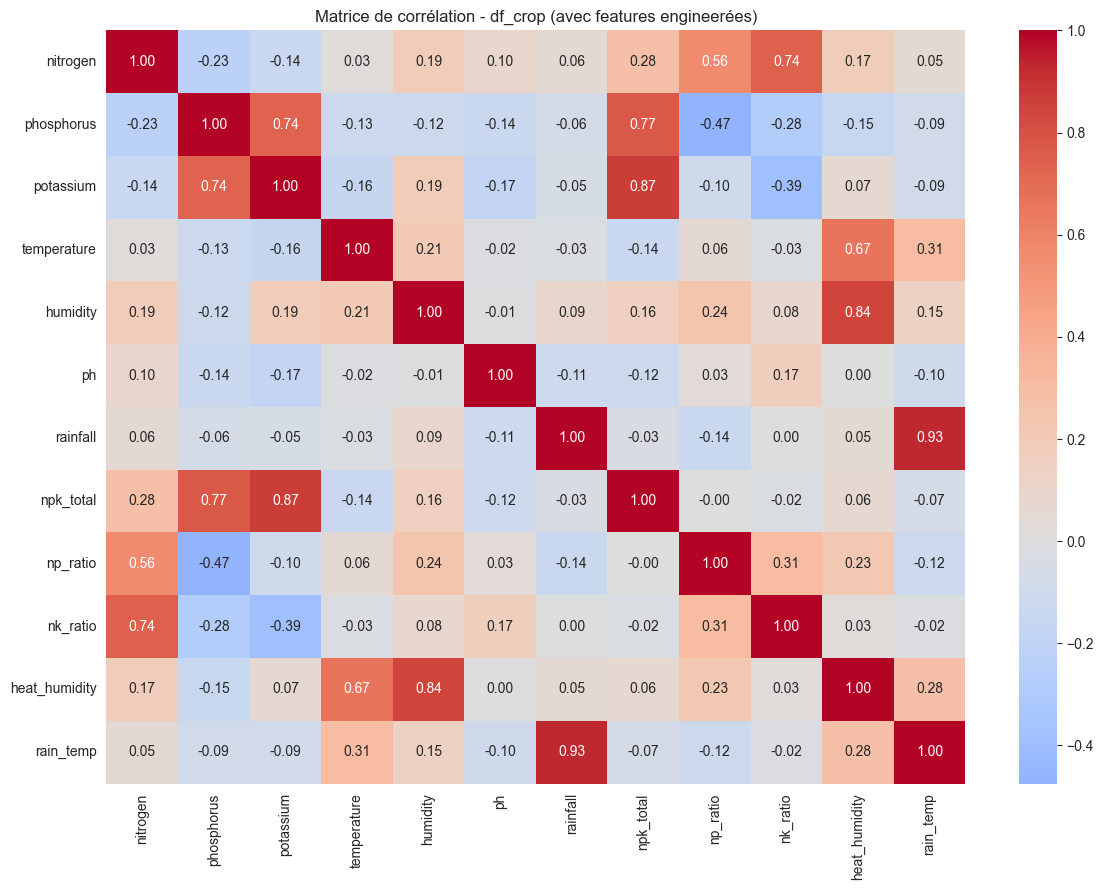

In [12]:
engineered_cols = ["npk_total", "np_ratio", "nk_ratio", "heat_humidity", "rain_temp"]
available_engineered = [c for c in engineered_cols if c in df_crop.columns]
corr_cols = numeric_cols + available_engineered

plt.figure(figsize=(12, 9))
corr = df_crop[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Matrice de corrélation - df_crop (avec features engineerées)")
plt.tight_layout()
plt.show()

## 8. Évolution du rendement dans le temps (df_yield)

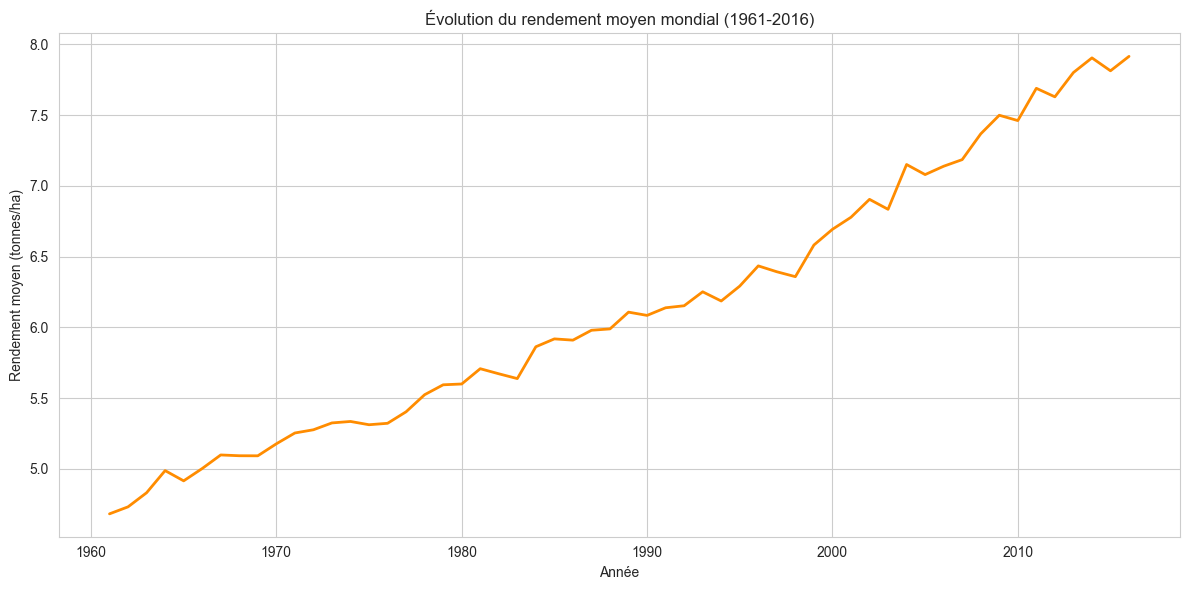

In [13]:
plt.figure(figsize=(12, 6))
yearly_avg = df_yield.groupby("year")["yield_tonnes_per_ha"].mean()
yearly_avg.plot(kind="line", color="darkorange", linewidth=2)
plt.title("Évolution du rendement moyen mondial (1961-2016)")
plt.xlabel("Année")
plt.ylabel("Rendement moyen (tonnes/ha)")
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Cultures à plus fort rendement moyen

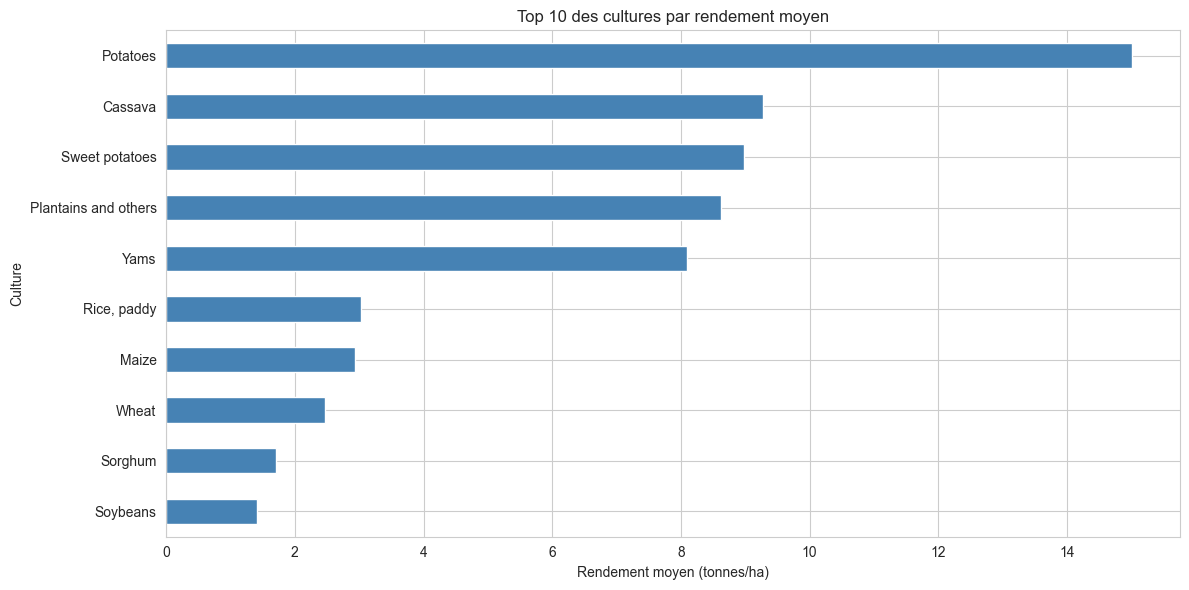

In [14]:
plt.figure(figsize=(12, 6))
top_crops = df_yield.groupby("crop")["yield_tonnes_per_ha"].mean().sort_values(ascending=False).head(10)
top_crops.plot(kind="barh", color="steelblue")
plt.title("Top 10 des cultures par rendement moyen")
plt.xlabel("Rendement moyen (tonnes/ha)")
plt.ylabel("Culture")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Conclusion de l'EDA

**Qualité des données**
- Aucune valeur manquante détectée dans `df_crop` et `df_yield`
- Aucun doublon détecté
- 8 lignes sur 56 717 ont un rendement à 0 (0.01%) — concentrées sur "New Caledonia" (Sorghum, Wheat), probablement une vraie donnée (récolte nulle), volume négligeable

**df_crop (recommandation de culture)**
- Dataset parfaitement équilibré : 100 échantillons par culture (22 cultures) → pas besoin de rééquilibrage pour le futur modèle de classification
- Corrélation notable : phosphore ↔ potassium (0.74) — justifie les features `np_ratio` / `nk_ratio`
- Aucune valeur aberrante bloquante observée dans les boxplots

**df_yield (rendement agricole)**
- Tendance claire à la hausse : rendement mondial moyen × ~1.7 entre 1961 (~4.7 t/ha) et 2016 (~7.9 t/ha)
- Les tubercules (Potatoes, Cassava, Sweet potatoes, Yams) ont le rendement moyen le plus élevé, cohérent agronomiquement

**Prochaines étapes**
- Feature Engineering déjà intégré dans les modèles dbt (`mart_crop_recommendation`, `mart_yield`), aligné avec le pipeline d'inférence ML (Personne 5)
- Le renommage de colonnes (`nitrogen` → `N`, etc.) doit être fait côté script d'inférence Python, pas dans dbt